# Küresel Petrol Fiyatları | 2026 Amerika - İran Savaşının Etkileri ~ Regresyon Modellemesi

### Giriş
#### Neden Bu Ödevi Yapıyorum - Amacım Ne ? 
Öncelikle savaş nedeniyle dünya genelinde petrol ve küresel ekonomiler de byük zorlanmalar ve farklı gelişmeler yaşandı. Bunu gayet iyi bu 1 aylık süreç içerisinde gördük ve öğrendik. Orta Doğuda ki bu problem tahminsel mekanizmaları geliştirme yönünde bize sinyal veriyordu. Ben de bu nedenle kodlarımı ve modelimi bu yönde eğitmek ve tasarlamak istedim. Model aldığı veri seti değerleri ile bizlere ilerleyen dönemler de bazı çıktı değerleri tahmin mekanizması ile verecek. Bu yönde veri setim üzerinde çalışmaya başladım. Tabi ki veri setim küçük olduğu için modelin tahmin ve öğrenme süreçlerin de bazı zorluklar ve yanlışlıklar aldım en optimum süreci elde edemedim. Fakat ödevin gerektirdiği gibi amacım bir modelin nasıl tasarlanabileceği konusunda yeterliliğimi geliştirmekti.

- Hürmüz boğazının kapatılması nedeniyle petrol fiyatları dünyanın her bir yerinde anlık olarak çok büyük bir yükselişe geçti.
- Dünya bunun yükünü sadece şu an değil ilerleyen dönemlerde ve yıllar da da çokça görecek ve taşıyacak.
- Bende bu nedenle ödevimi bu yönde ve bu konuda bir veri seti ile hazırlamak istedim.
- Çünkü bu konu hakkında yapılabilecek tahmin mekanizmaları benim de yakından ilgilendiğim ve merak ettiğim bir konu.

In [133]:
# Gerekli kütüphaneleri yapacağım proje için import ediyourum burada 
# Daha sonra uyarıları engellemek için warnings kütüphanesini ekliyorum
import warnings
warnings.simplefilter("ignore")

# Öncelikle pandas kütüphanesini importladım
import pandas as pd

# Burada da eklediğim csv dosyasını okumasını sağlıyorum sistemin
df = pd.read_csv("petrol_prices_comparison.csv")

# Sayısal verileri okusun diye numpy kütüphanesini ekledim
import numpy as np

#### Açıklamalarım

Modeli hazırlama ve importları ekleme işlemlerini bu kısımda hazırladım.
- Zaten importlarımızı eklemezsek ileri de yapacağımız işlemlerde problem yaşarız ben de bu nedenle projeye en başta öğretilen şekilde importları ekledim.
- Gerekli kütüphaneleri sisteme ekledim.

### Veri Setimi Hazırlıyorum

In [134]:
df.head()
# Burada veri setimizi görüyoruz (tabi ki ilk 5 verisi) bilgi sahibi olmak için

,Country,ISO,Region,Currency,Before_War_Price,Mar7_Price,Unit,Amount_Change,Pct_Increase,Trend,Before_War_USD,Mar7_USD,Oil_Import_Dep
0,Pakistan,PAK,South Asia,PKR,266.17,321.17,PKR/L,55.0,20.66,Increase,0.95,1.15,High
1,India,IND,South Asia,INR,94.77,94.77,INR/L,0.0,0.00,Stable,1.14,1.14,High
2,Bangladesh,BGD,South Asia,BDT,125.00,130.00,BDT/L,5.0,4.00,Increase,1.02,1.06,High
3,Afghanistan,AFG,South Asia,AFN,57.00,57.00,AFN/L,0.0,0.00,Stable,0.82,0.82,High
4,Nepal,NPL,South Asia,NPR,186.00,190.00,NPR/L,4.0,2.15,Increase,1.40,1.43,High


#### Açıklamalarım
Burada **head** komutu ile veri setimin ilk 5 satırını görünür hale getirdim.

In [135]:
df = pd.get_dummies(df, drop_first=True)
# Bu şekilde kategorik ve metin türündeki verileri sayısal verilere çeviriyoruz.
# Bunun nedeni modelin verileri kullanabilmesini sağlamak.
# Çünkü model sayısal veriler kullanarak bize tahminler üreteceği için bu şekilde kullandım

# Daha sonrasında sizler için ilk 5 ' er veriyi görüntüledim.
print(df.head())

   Before_War_Price  Mar7_Price  Amount_Change  Pct_Increase  Before_War_USD  \
0            266.17      321.17           55.0         20.66            0.95   
1             94.77       94.77            0.0          0.00            1.14   
2            125.00      130.00            5.0          4.00            1.02   
3             57.00       57.00            0.0          0.00            0.82   
4            186.00      190.00            4.0          2.15            1.40   

   Mar7_USD  Country_Bangladesh  Country_China  Country_Germany  \
0      1.15               False          False            False   
1      1.14               False          False            False   
2      1.06                True          False            False   
3      0.82               False          False            False   
4      1.43               False          False            False   

   Country_India  ...  Unit_BDT/L  Unit_INR/L  Unit_LKR/L  Unit_NPR/L  \
0          False  ...       False       Fal

#### Açıklamalarım
- Kod bloğunda gördüğümüz **get_dumnies** kısmı veri setimdeki gördüğümüz kategorik veri olan yerlerin sayısala çevrilme yeri aslında.
- Yani ben bu kodlarda get_dumnies yapmasaydım sizlerle ilerleyen süreçte gerçekten bazı hatalarla karşı karşıya kalabilrdik.

#### Bağımlı ve Bağımsız Değişkenlerimi Belirliyorum

In [136]:
x = df.drop(["Mar7_USD", "Mar7_Price"], axis=1)
# Modelin cevap kısmını görmesini engelemek için burada o sütunları çıkardım.
# Bu şekilde işlemime devam ettim.

# Aslında model USD ve Price sütunlarını tahmin edecek ve bize çıktı verecek.

# Bu yüzden biz bu sütunları çıkardık ki onları tahmin ederken kullanmasın.

# Zaten bize çıktı sürecinde vereceği sütunları tahmin ederken kullanması saçma olur

y = df["Mar7_USD"]

#### Açıklamalarım
- Burada temel amaç bizim modelin çıktı olarak vereceği **price ve USD** alanlarını işlem sırasında kullanmasını engellemektir.
- Yukarıda da gördüğümüz gibi drop ile 2 farklı sütunu işleme almadan çıkmasını sağladım. Çünkü bunu yapmasam model bunları çıktı olarak vereceği yer de tekrar işlem yaparken kullanır.
- Ama zaten benim istediğim model bana bunlarla ilgili çıktı üretsin.

#### Eğitim ve Test Verilerimi Ayırıyorum

In [137]:
from sklearn.model_selection import train_test_split
# Burada train-test-split yani eğitim ve test verilerimi ayırarak,
# Modelimin eğitim için ve test için kullanacağı verileri ayırıyorum.

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Burada ise gördüğümüz gibi test_size verdik,
# Bu bizim test boyutumuzun verilerden %20 lik bir kısmı kullanmasını sağlar.
# Random state kısmı ise, 
# Yaptığı her işlemde aynı şekilde veriyi bölmesini sağlıyoruz aslında.

#### Açıklamalarım
- Modelimizin asıl olarak test ve eğitim aşaması burada ki **train_test_split** metodu ile gerçekleşmektedir.

- Ayrıca **test_size** ve **random_state** ile modelin veri setinin %20 kısmını test olarak kullanamsını, aynı şekilde her işlemde veriyi aynı şekilde eşit parçalarla bölüp kullanmasını sağladım.

- Zaten ders içerisinde işlemiş olduğumuz pdfler de de öğrendiğim gibi bu sistemi burada da uyguladım.

- Her aşamayı düzenli bir biçimde uyguladım.

In [138]:
import tensorflow as tf
# Burada da tensorflow kütüphanemizi import ediyorum.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Bu iki satır ise bize modeli katman katman ayırmamızı,
# Ve bu şekilde işlemleri halletmemizi sağlar.

#### Açıklamalarım
- Burada ise tensoflow kütüphanemizi import ettik.
- Ayrıca modeli **katman katman ayırdık**
- Bunu yapmamın sebebi sırayla ve katmanlı bir yapıyla çalışmaktı açıkçası.

#### Veri Ölçeklendirme Aşamasını Yapıyorum

In [139]:
from sklearn.preprocessing import StandardScaler
# Burada veriyi standartlaştırmak amacıyla kütüphane importladım

x_scaler = StandardScaler()  
# Burada da verdiğimiz giriş verilerini ölçekledim

y_scaler = StandardScaler()  
# Burada da hedef olan yani çıkışta verilecek ve ulaşmaya çalıştığımız verileri ölçekledim

x_train = x_scaler.fit_transform(x_train)  
# Burada verinin ortalamasını ve dağılımını gösterdim

x_test = x_scaler.transform(x_test)  
# Standart ise veriyi standart hale çevirir

y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))

#### Açıklamalarım
- **Standardizasyon** yapmak için burada gerekli kütüphaneyi import ettik.
- Aynı şekilde eklediğim giriş verilerini yani kullanılacak verileri standart hale getirdim.
- Daha sonra verilerin ortalamasını ve dağılımını gösterdim.
- Yani model verileri kullansın diye bu verileri en standart hale getirmeye çalıştım.
- Bu sürece de standardizasyon denir.

#### Neden Scale Yaptım ? Amacım Neydi ? 
- Çünkü modelimin çalışırken aynı ölçekte ve aynı aralıkta değerlerle çalışmasını istedim ben.
- Bu yüzden de veri setimdeki verileri standizasyona tabi tutarak ölçeklendirip modelin kullanımına aldım.
- **StandartScale** ile bu işlemi yaptım.

#### Model Oluşturma 

In [140]:
model = Sequential()

# Daha derin ve düzenli mimari
model.add(Dense(32, activation="relu", input_shape=(x_train.shape[1],)))
model.add(Dropout(0.2))                    # Overfitting'i önler
# Burada ilk katmanı ekledik, relu fonksiyonu hızlı çalıştığı için bunu ekledim ve overfitting engelledim.

model.add(Dense(16, activation="relu"))
model.add(Dropout(0.2))
# Aynı şekilde dropout ekleyerek modelin veriyi ezberlemesini engelleyerek daha iyi öğrenmesini sağladım.

model.add(Dense(8, activation="relu"))

model.add(Dense(1))                        # Çıkış katmanı (Mar7_USD tahmini)
# Çıkış katmanınının görevi ise bizim için gerekli son tahmini üretmektir.

#### Açıklamalarım
- Layer yani katman mantığı ile çalışmaya devam etmek istedim.
- Çıkış katmanının görevi ise bizim için gerekli son tahmini üretmektir.
- Aslında amacım burada ezber olayının önüne geçmek. Yoksa model tahmin sırasında ezber ile çalışır.
- Ben de bu nedenle dropout kullandım.
- Bu şekilde model daha sağlıklı çalışır.

#### Modelimi Neden Bu Şekilde Oluşturdum ?
- Burada yapmak istediğim aslında modelin aşırı düşinmesini engellemek (overfitting)
- Yani ben model gereksiz bilgi taşımasın istedim bunu boşuna kullanmasının önüne geçtim aslında bu aşamada.
- Buradaki katman mantığını ben de zor anladım ama araştırıp öğrendim.
- Aslında mantık basit, modele burada verdiğimiz nöron sayılarını mantık olarak bir insan beynindeki nöron çalışma mantığına benzetebilirim dedim,
- Yani ne kadar fazla bir alan ve nöron tanımlarsam model geniş bir biçimde öğrenir dedim, fakat daha az nöron belli bir kısıt ile modelin öğrenmesini sağlar ve kritik bilgileri bu kısıtlı alanda saklar diye düşündüm.

#### 8 - 16 -32 Mantığını Neden Uyguladım ?
- **32 (ilk katman)** => Bizim aslında en fazla nöron bulundurduğumuz yer bu da en fazla bilgiyi tutmak demek. Daha fazla özellik öğrenir.
- **16 (orta katman)** => Burada modele git, gereksiz bilgileri elemeye başla dedim.
- **8 (son katman)** => Burada da en son katmanı gösterdim. Dedim ki bana en önemli ve kritik bilgileri al diğerlerini bırak gel. Bu şekilde filtreleme yaptım.
- Aynı şekilde model bilgiyi yavaş yavaş sıkıştırarak gider. Eğer çok büyük olursa **overfitting** olur.

#### Neden Dropout Kullandım Peki ? 
- Bunun nedeni açık, kısaca overfitting engellemek ve farklı tahmin yollarını da kullanmasını sağlamak için.

#### Peki Neden ReLu Kullandım Ama Diğerlerini Kullanmadım ? 
- **ReLu** hesaplamayı çok hızlı yaptım ki bu da benim projem için gerçekten çok faydalı oldu.
- Hem de araştırdığım kadar bu yöntem derin öğrenme içinde artık bir standart olmuş.
- Aynı şekilde hesaplama aşamasında bana maliyeti daha az olduğu için eğitim süreci hızlı ilerliyordu.
- Sigmoid ise çıktıları 0 - 1 arasına sıkıştırıyor bu da tahmin sırasında bana problem yaşatabilirdi.
- **Kaggle**, **github** gibi pplatformlar da yapılan araştırma ve ödevler de de bu mantıkta yapılar gördüm bende bunu kullanmak istedim ve tercih ettim.
- **Sigmoid** ne diye araştırdım bunun da benim projem için kullanılabileceiğini pek düşünmedim çünkü sigmoid derin modeller de etkili değilmiş verim açısından ben de bunu kullanmadım.
- Aynı şekilde sigmoid çıktı aralığını sınırlıyor bu da derin ağlar da **vanishing gradient** problemi ile model öğrenmesini küçültüyor.
- Aynı şekilde **Tanh** ne diye kısaca baktım aynı şekilde yapay zekaya da sordum neden olup olmayacağını bir önceki gibi derin ağlarda problem olur performans düşer dedi.
- Bende tüm bunları göz önüne alarak en stabil olanı kullanma yoluna gittim.

#### Açıklamalarım
- **Layer** mantığı ile çalışmayı devam ettirdim.
- Çıkış katmanınının görevi ise bizim için gerekli **son tahmini** üretmektir.

In [141]:
model.summary()

# Düz mantık summary kurduğumuz yapay sinir ağının özetini bize gösterir

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                     │ (None, 32)                  │           1,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Model Derleme ve Eğitim 

In [142]:
model.compile(
    optimizer="adam",
    loss="mse"
)
# Burada modeli eğitime hazır hale getiriyoruz

#### Neden Adam Kullandım Fakat SGD Kullanmadım Açıklayayım
- Çalışmayı yaparken ve geliştirirken optimizasyon algoritması olarak adam kullandım.
- Çünkü adam algoritması her bir parametre için öğrenme oranını ayrı ayrı güncelleyerek daha hızlı ve ve normal bir öğrenme sürecini bana sağladı. Ben de bu yüzden tercih ettim.
- Fakat SGD sabit öğrenme oranına sahip bu yüzden daha yavaş bir öğrenme süreci verebilirdi bana.
- Aslında SGD de kullanılabilirdi ama daha yavaş kalabileceğini öğrendim.
- Aynı şekilde öğrenme sürecinde model için daha fazla ayar yapmam gerekiyordu.
- Veri setim küçük olduğu ve adam hızlı sonuç vereceği için ben de **adam** kullandım.

In [143]:
from tensorflow.keras.callbacks import EarlyStopping

# Early Stopping modelin uzun süre eğiitlmesinden korumayı sağlar bize.
# Yani model artık iyileşmeye gitmezse eğitimi durdurur ve aşırı öğrenme olmaz.

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Burada eksik kaldığım noktada yapay zeka araçları ile yardım aldım.
# Öğrendiğim bilgi kısaca model epoch yani baştan sona tüm öğrenme sürecini görür,
# Eğer gelişme yoksa süreci durdurur.

#### Açıklamalarım
- Sistemin fazla ve uzun süre eğitilmesini engellemek gerekir.
- Bu nedenle ben de **EarlyStopping** kullandım.
- Bu sistem ile verdiğimiz bu yönlendirme **epoch** sayısı aşıldıktan sonra tüm öğrenme sürecini durdurmasını sağladım.

In [144]:
history = model.fit(
    x_train, y_train,
    # Bunlar modelin eğitim verileri
    # Bizim için model bunları öğrenmek için kullanır.
    
    validation_data=(x_test, y_test),
    # Bunlar da kullanacğı test verileri, model bunlarla ilk kez karşılaşır.
    
    epochs=150,
    # Bu kısım ise modelin 150 kez iyileşmeye çalışması tahmin mekanizmasında.
    
    batch_size=32,
    # Model burada her seferinde 32 parça şeklinde alır örnekleri,
    # Ve kendini sonra günceller.
    
    callbacks=[early_stop],
    # Bu da erken durma kısmı, yani epoch bitti diyelim,
    # İyileşme yoksa model süreci durdurur.
    
    verbose=1
    # Eğitim ilerlemesini gösterir.
)

Epoch 1/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.8874 - val_loss: 0.9212
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 1.3500 - val_loss: 0.8684
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.8636 - val_loss: 0.8209
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.8969 - val_loss: 0.7810
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 1.9672 - val_loss: 0.7576
Epoch 6/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 1.2383 - val_loss: 0.7350
Epoch 7/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - loss: 1.0124 - val_loss: 0.7089
Epoch 8/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.7865 - val_loss: 0.6732
Epoch 9/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 1.5258 - val_loss: 0.6401
Epoch 10/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - loss: 0.7005 - val_loss: 0.6067
Epoch 11/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 0.9681 - val_loss: 0.5719
Epoch 12/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 1.2330

#### Açıklamalarım
- Aslında burada modele ilk kez karşılaşacağı ve öğreneceği verileri verdim.
- Daha sonra ise **Epoch** ile 150 kez iyileşme çalışması yapmasını sağladım.
- Sonra da iyileşme yoksa **early_stop** çağırdım.
- Ve eğitimin ilerlemesini gösterdim.

#### Tahmin ve Modeli Değerlendirme

In [145]:
tahmin = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


In [146]:
from sklearn.metrics import r2_score, mean_squared_error
# Burada doğrulama metriği olarak r2 score ve mse kullandım.

# tahminleri üret
tahmin = model.predict(x_test)
# Model test verisi yani x_test bakarak tahmin yapar.

# R-kare skoru
print("R2 Score:", r2_score(y_test, tahmin))
# Modelin ne kadar doğru tahmin yaptığını gösterir,
# 1 e yakınsa çok iyi 0 a yakınsa kötüdür.

# RMSE değeri
print("RMSE:", mean_squared_error(y_test, tahmin) ** 0.5)
# Tahmin ile gerçek arasındaki farka bakar,
# Mantıken ne kadar küçükse o kadar iyi olmasını bekleriz.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
R2 Score: 0.8989123472414927
RMSE: 0.38870688742361303


#### Açıklamalarım
- Doğrulama metriklkeri olarak **R2 score ve MSE** kullandım.
- Aynı şekilde tahmin için **x_test** verisine bakıyor sistem.
- R2 score ise bizim modelin ne kadar doğru tahmin yaptığına bakar.
- Eğer **1'e yakınsa** çok iyi **0'a yakınsa** kötüdür.
- RMSE ise ne kadar küçükse o kadar iyidir.
- Mantıken gerçek ile tahmin yakın olursa iyi olur sistem, ben de buna göre yaptım kodları.

#### Neden R2 Kullandım ? Amacım Neydi ? 
- Ben R2 score kullandım ve modelin veriye uyum gösterdiğini anladım.
- Ama bunu kullanmak benim modelime az da olsa ezber yapmaya yönlendirmiş oldu.
- Yani gerçek hayatta modelim aynı verimliliği göstermeyebilir.

In [147]:
# Ölçeklenmiş tahminleri gerçek değerlere çeviriyorum
tahmin_gercek = y_scaler.inverse_transform(tahmin)
y_test_gercek = y_scaler.inverse_transform(y_test)

# Gerçek değerlerle tekrar bakalım
print("Gerçek (unscaled) R2 Score:", r2_score(y_test_gercek, tahmin_gercek))
print("Gerçek (unscaled) RMSE:", mean_squared_error(y_test_gercek, tahmin_gercek) ** 0.5)

Gerçek (unscaled) R2 Score: 0.898912335835888
Gerçek (unscaled) RMSE: 0.15284055741869626


#### Açıklamalarım
- İlk yazdığım kodda standardizasyon yaptığım verileri kullandım. 
- Şimdi ise değerleri ilk haline geri çevirdim ki aradaki farkı da görelim.
- Böylece modelin gerçek hayattaki performansını daha iyi ortaya koymuş oldum.

#### Son Olarak Süreci Görselleştirdim

<Axes: >

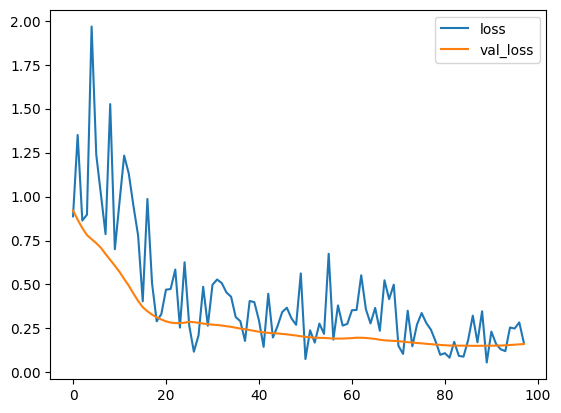

In [148]:
loss_f = pd.DataFrame(history.history)
loss_f.plot()

#### Açıklamalarım
- Burada **loss ve validation_loss** değerlerinin epochlara göre değişimini görüyoruz.
- Modelin değişim sürecinde hataların farklılıklarına ve değişimlerine dikkat çeken bir grafik olarak karşımıza çıkar.

#### Öğrenci Yorumum 
Öncelikle gerçekten derste öğrendiğimi burada uygulamak çok zor geldi. Çünkü gerçekten sizin de söyledğiniz gibi yapay zeka kullanmak beni çok fazla köreltmiş ve kod yazma konusunda ayrıca kendi başıma bir şeyleri manuel yapma konusunda yormuş. Fakat bu ödev bana üniversite ilk sınıfta daha yeni yapay zekanın çıkacağı fakat bizim aktif kullanmadığımız zamanları hatırlattı. Yani kendi emeğim ve beyin gücümle yapmak bir yanan yorucu olsa da bir şeye emek vermenin ne kadar güzel ve sonunda başarının verdiği tatlı dopaminin heyecanınını yaşadım. Ayrıca arkadaşlarımla karşılaştırmalar da bulunarak kendi eksiklerimi kapattım. Bu da beni daha ilerye taşıdı. Ödevin asıl amacı bence daha çok kendi kendimize çalışmak ve başarmak oldu. Bunun için teşekkürler sayın hocam. Umarım yaptığım ödevi beğenirsiniz. Ayrıca sizi temin ederim ki dediğiniz gibi yapay zekayı bir mini asistan gibi aldığım hatalar da ve küçük noktalar da kullandım ama ödevim tamamen kendi elimle hazırladığım bir proje oldu. Tekrardan teşekkürler.

#### Sonuç ve Yorumum

- Veri setimi kaggle den buldum.
- İlk olarak karışık gelmesi nedeniyle biraz zorlandım.
- Daha sonra veri setim üzerinde ne yapabileceğimi düşündüm.
- Ardından da github üzerinden bazı pdfleri inceledim.
- Yapay zeka yardımı ile bazı kısımlar da ki hatalarımı anladım (Çok az miktarda kullandım)
- Regresyon modelinin sürecini ve çıktısını anladım.
- Derste öğrendiğim teorik bilgileri burada bir miktarda olsa uygulamaya dökebildim

- Yani nihayetinde baktığımızı zaman petrol fiyatları ile savaşlar arasındaki bir ilişki analizi yapmaya çalıştım. Model kötü sonuç vermedi ama veri setim küçük bu nedenle sonuçların kesin olduğunu söylemek doğru olmaz.
- Yani modeli daha fazla veri ile çalıştırırsam daha iyi sonuçlar elde edebilirim.
- Model geliştirmeye açıktır.

#### Teşekkürler